<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **naive bayes works well with the error**

# ***1. Bayes Theorem***


# P(A/B)=P(B/A) P(A)/ P(B)
P(A)- EVENT OCCUR(Prior Probability)

P(B)- EVIDENT (Marginal probability)

P(A/B) -posterior Probability

P(B/A)- Likelihood






Step 1- Frequency Table

Step 2- Likelihood Table

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/DATASET /Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


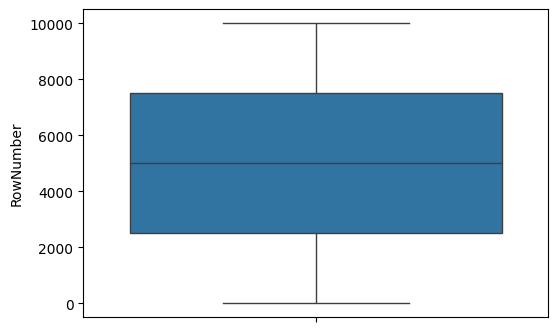

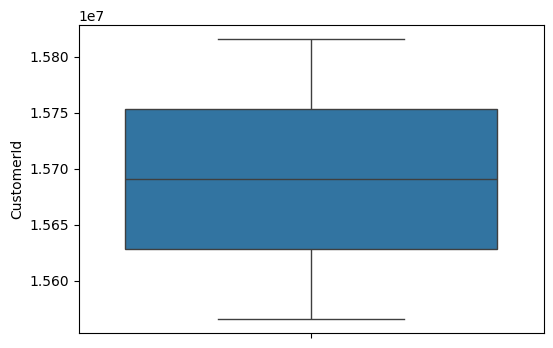

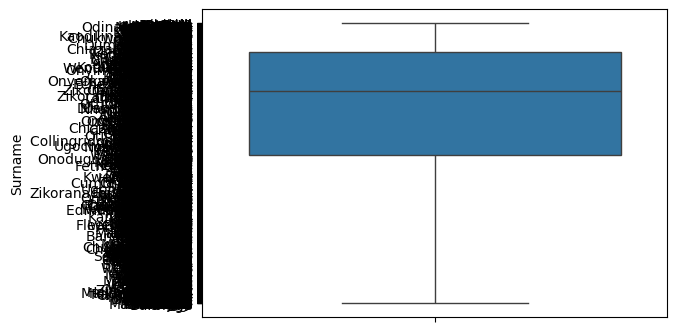

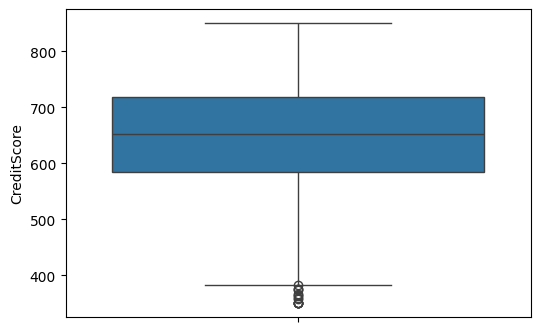

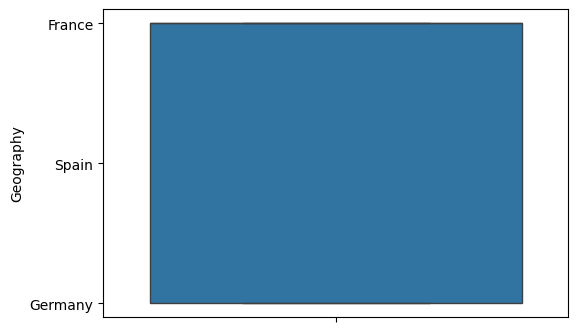

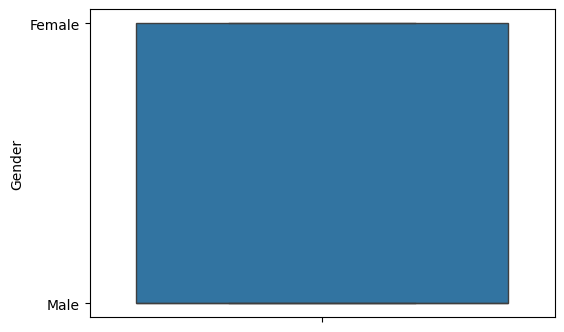

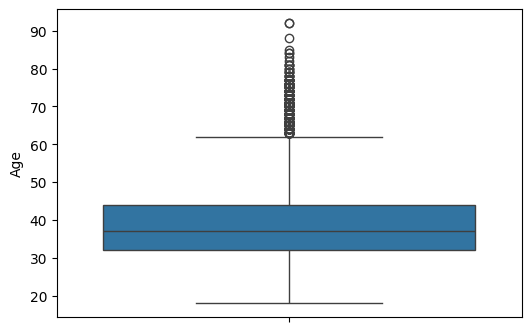

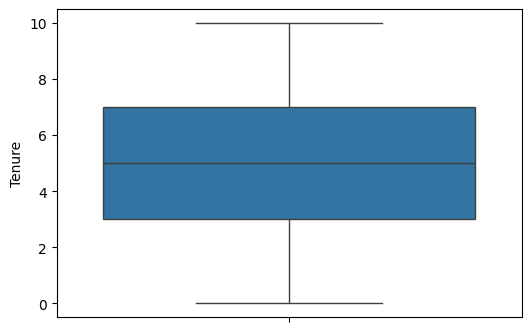

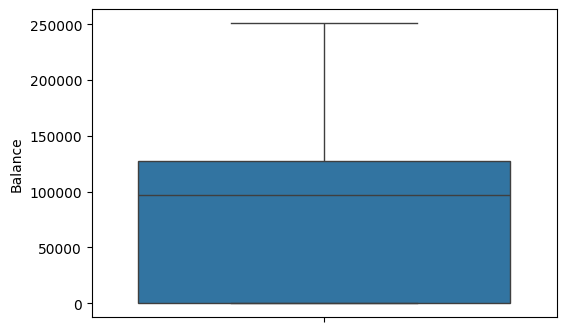

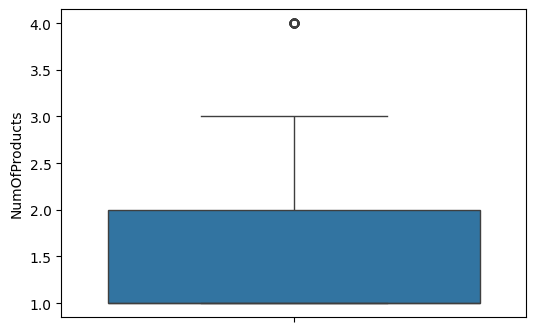

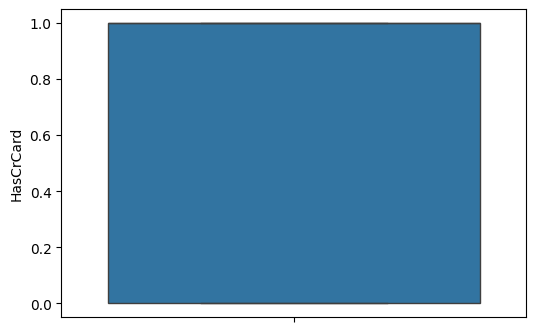

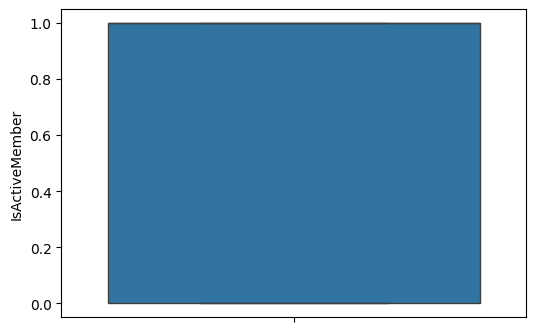

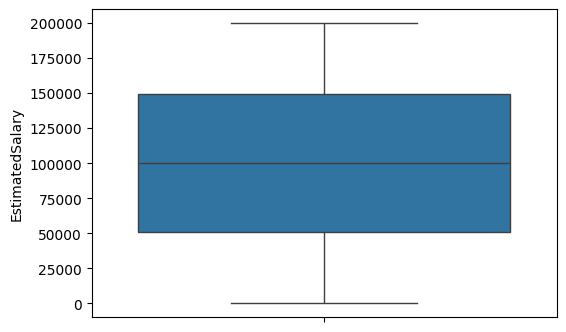

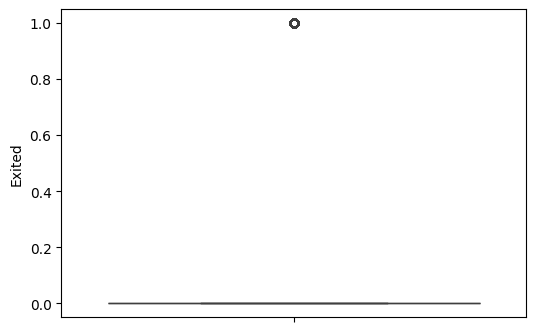

In [ ]:
for col in df.columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])

In [ ]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1)
df['outlier']=iso.fit_predict(df[['Age']])
df=df[df['outlier']==-1]

In [ ]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1)
df['outlier1']=iso.fit_predict(df[['Balance']])
df=df[df['outlier1']==-1]

In [ ]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,outlier,outlier1
75,76,15780961,Cavenagh,735,France,Female,21,1,178718.19,2,1,0,22388.00,0,-1,-1
284,285,15708608,Wallwork,799,France,Female,22,8,174185.98,2,0,1,192633.85,0,-1,-1
696,697,15727299,Edgar,445,Spain,Male,62,1,64119.38,1,1,1,76569.64,1,-1,-1
1285,1286,15658532,Nnamutaezinwa,520,Spain,Female,63,5,162278.32,1,1,1,34765.33,0,-1,-1
1327,1328,15688007,Liu,703,Spain,Male,20,3,165260.98,1,1,1,41626.78,0,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9646,9647,15603111,Muir,850,Spain,Male,71,10,69608.14,1,1,0,97893.40,1,-1,-1
9671,9672,15636061,Pope,649,Germany,Male,78,4,68345.86,2,1,1,142566.75,0,-1,-1
9688,9689,15730579,Ward,850,France,Male,68,5,169445.40,1,1,1,186335.07,0,-1,-1
9761,9762,15736778,Adams,807,Germany,Female,60,1,72948.58,2,1,1,17355.36,0,-1,-1


In [ ]:
df=df.drop(columns='RowNumber',axis=1)

In [ ]:
df


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,outlier,outlier1
75,15780961,Cavenagh,735,France,Female,21,1,178718.19,2,1,0,22388.00,0,-1,-1
284,15708608,Wallwork,799,France,Female,22,8,174185.98,2,0,1,192633.85,0,-1,-1
696,15727299,Edgar,445,Spain,Male,62,1,64119.38,1,1,1,76569.64,1,-1,-1
1285,15658532,Nnamutaezinwa,520,Spain,Female,63,5,162278.32,1,1,1,34765.33,0,-1,-1
1327,15688007,Liu,703,Spain,Male,20,3,165260.98,1,1,1,41626.78,0,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9646,15603111,Muir,850,Spain,Male,71,10,69608.14,1,1,0,97893.40,1,-1,-1
9671,15636061,Pope,649,Germany,Male,78,4,68345.86,2,1,1,142566.75,0,-1,-1
9688,15730579,Ward,850,France,Male,68,5,169445.40,1,1,1,186335.07,0,-1,-1
9761,15736778,Adams,807,Germany,Female,60,1,72948.58,2,1,1,17355.36,0,-1,-1


In [ ]:
from sklearn.preprocessing import LabelEncoder
lc=LabelEncoder()
df['Gender']=lc.fit_transform(df['Gender'])

In [ ]:
df = df.drop(columns=['outlier', 'outlier1'], errors='ignore')


In [ ]:
X=df[['CustomerId','CreditScore','Gender','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']]
y=df['Exited']

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.naive_bayes import BernoulliNB
model =BernoulliNB()
model.fit(X_train,y_train)



BernoulliNB()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,classification_report
print("Accuracy score:",accuracy_score(y_test,y_pred))
print("Classification Report:",classification_report(y_test,y_pred))


Accuracy score: 0.8947368421052632
Classification Report:               precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.50      0.67         4

    accuracy                           0.89        19
   macro avg       0.94      0.75      0.80        19
weighted avg       0.91      0.89      0.88        19

